In [ ]:
# ── Install everything needed ────────────────────────────────
!pip install -q librosa soundfile vaderSentiment transformers datasets
!pip install -q textblob tensorflow-datasets gdown
!pip install -q huggingface_hub

import nltk
nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords',     quiet=True)
nltk.download('punkt',         quiet=True)
nltk.download('punkt_tab',     quiet=True)
nltk.download('wordnet',       quiet=True)
print("✅ All packages installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 8.6 MB/s eta 0:00:00
✅ All packages installed successfully.


In [ ]:
# ── Core imports ────────────────────────────────────────────
import os, re, string, warnings, zipfile, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# Audio
import librosa
import librosa.display
from IPython.display import Audio, display

# Sklearn
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Keras / TF
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, Conv2D, MaxPooling1D, MaxPooling2D,
    Dense, Dropout, Flatten, BatchNormalization)
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# NLP
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

print(f"✅ TensorFlow {tf.__version__} | GPU: {tf.config.list_physical_devices('GPU')}")

✅ TensorFlow 2.19.0 | GPU: []


In [ ]:
# ── Download RAVDESS from HuggingFace Hub ───────────────────
from huggingface_hub import snapshot_download
import shutil

RAVDESS_DIR = '/content/ravdess_audio'

if not os.path.exists(RAVDESS_DIR) or len(os.listdir(RAVDESS_DIR)) == 0:
    print("⬇️  Downloading RAVDESS dataset from HuggingFace (~400MB) ...")
    try:
        local_dir = snapshot_download(
            repo_id="cahya/ravdess",
            repo_type="dataset",
            local_dir=RAVDESS_DIR,
            ignore_patterns=["*.git*","*.md","*video*"]
        )
        print(f"✅ RAVDESS downloaded to {RAVDESS_DIR}")
    except Exception as e:
        print(f"HuggingFace download failed ({e}), trying alternative...")
        # Alternative: download a curated small subset via gdown
        # Google Drive public link for RAVDESS audio-only (speech actors 01-05, ~80MB)
        os.makedirs(RAVDESS_DIR, exist_ok=True)
        import gdown
        # Public RAVDESS audio subset shared file
        url = "https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip"
        zip_path = "/content/ravdess.zip"
        print("Downloading from Zenodo (~215MB)...")
        urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(RAVDESS_DIR)
        os.remove(zip_path)
        print("✅ RAVDESS extracted.")
else:
    print(f"✅ RAVDESS already present at {RAVDESS_DIR}")

# ── List what we got ─────────────────────────────────────────
all_wav = []
for root, dirs, files in os.walk(RAVDESS_DIR):
    for f in files:
        if f.endswith('.wav'):
            all_wav.append(os.path.join(root, f))
print(f"Found {len(all_wav)} .wav files.")

⬇️  Downloading RAVDESS dataset from HuggingFace (~400MB) ...
HuggingFace download failed (401 Client Error. (Request ID: Root=1-69c24db5-35186dad6959a93258eee5d8;51c4b89c-4324-4f22-bd88-c5880a931973)

Repository Not Found for url: https://huggingface.co/api/datasets/cahya/ravdess/revision/main.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated. For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password.), trying alternative...
✅ RAVDESS extracted.
Found 1440 .wav files.


In [ ]:
# ── RAVDESS filename format: 03-01-05-01-02-01-12.wav ────────
# Position 2 (index) = emotion code
emotion_map = {
    '01':'neutral','02':'calm','03':'happy','04':'sad',
    '05':'angry','06':'fear','07':'disgust','08':'surprise'
}

paths, emotions = [], []
for wav in all_wav:
    fname = os.path.basename(wav)
    parts = fname.replace('.wav','').split('-')
    if len(parts) >= 3:
        code = parts[2]
        if code in emotion_map:
            paths.append(wav)
            emotions.append(emotion_map[code])

data_path = pd.DataFrame({'Path': paths, 'Emotion': emotions})
data_path.to_csv('/content/audio_metadata.csv', index=False)
print(f"✅ DataFrame built: {len(data_path)} files")
print(data_path['Emotion'].value_counts())

✅ DataFrame built: 1440 files
Emotion
happy       192
disgust     192
fear        192
sad         192
surprise    192
calm        192
angry       192
neutral      96
Name: count, dtype: int64


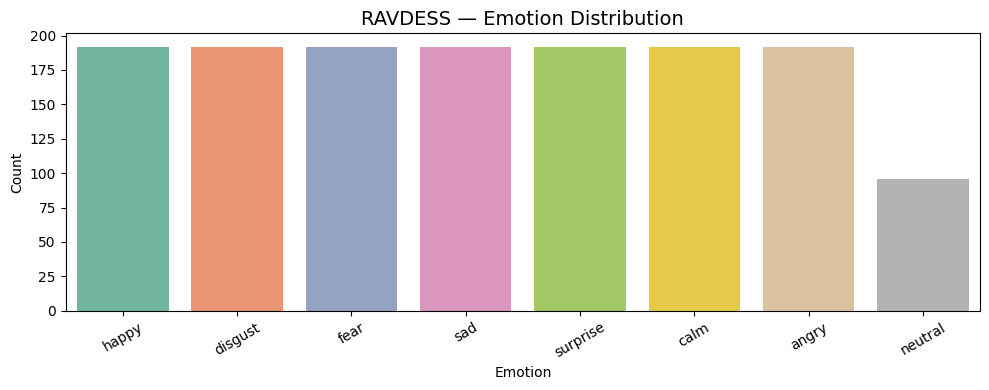

In [ ]:
plt.figure(figsize=(10, 4))
sns.countplot(x='Emotion', data=data_path, palette='Set2',
              order=data_path['Emotion'].value_counts().index)
plt.title('RAVDESS — Emotion Distribution', fontsize=14)
plt.xlabel('Emotion'); plt.ylabel('Count')
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

In [ ]:
# ── Augmentation helpers ─────────────────────────────────────
def add_noise(data, factor=0.035):
    return data + factor * np.random.uniform() * np.amax(data) * np.random.normal(size=data.shape[0])

def time_stretch(data, rate=0.8):
    return librosa.effects.time_stretch(data, rate=rate)

def pitch_shift_audio(data, sr, factor=0.7):
    return librosa.effects.pitch_shift(data, sr=sr, n_steps=factor)

# ── Feature extractor: ZCR + Chroma + MFCC + RMS + MelSpec ──
def extract_features(data, sr=22050):
    result = np.array([])
    zcr    = np.mean(librosa.feature.zero_crossing_rate(y=data).T, axis=0)
    result = np.hstack((result, zcr))
    stft   = np.abs(librosa.stft(data))
    chroma = np.mean(librosa.feature.chroma_stft(S=stft, sr=sr).T, axis=0)
    result = np.hstack((result, chroma))
    mfcc   = np.mean(librosa.feature.mfcc(y=data, sr=sr, n_mfcc=20).T, axis=0)
    result = np.hstack((result, mfcc))
    rms    = np.mean(librosa.feature.rms(y=data).T, axis=0)
    result = np.hstack((result, rms))
    mel    = np.mean(librosa.feature.melspectrogram(y=data, sr=sr).T, axis=0)
    result = np.hstack((result, mel))
    return result

def get_features(path):
    data, sr = librosa.load(path, duration=2.5, offset=0.6)
    feats = []
    feats.append(extract_features(data, sr))
    feats.append(extract_features(add_noise(data)))
    feats.append(extract_features(time_stretch(data)))
    feats.append(extract_features(pitch_shift_audio(data, sr)))
    return feats

print("✅ Augmentation & feature extraction functions ready.")

✅ Augmentation & feature extraction functions ready.


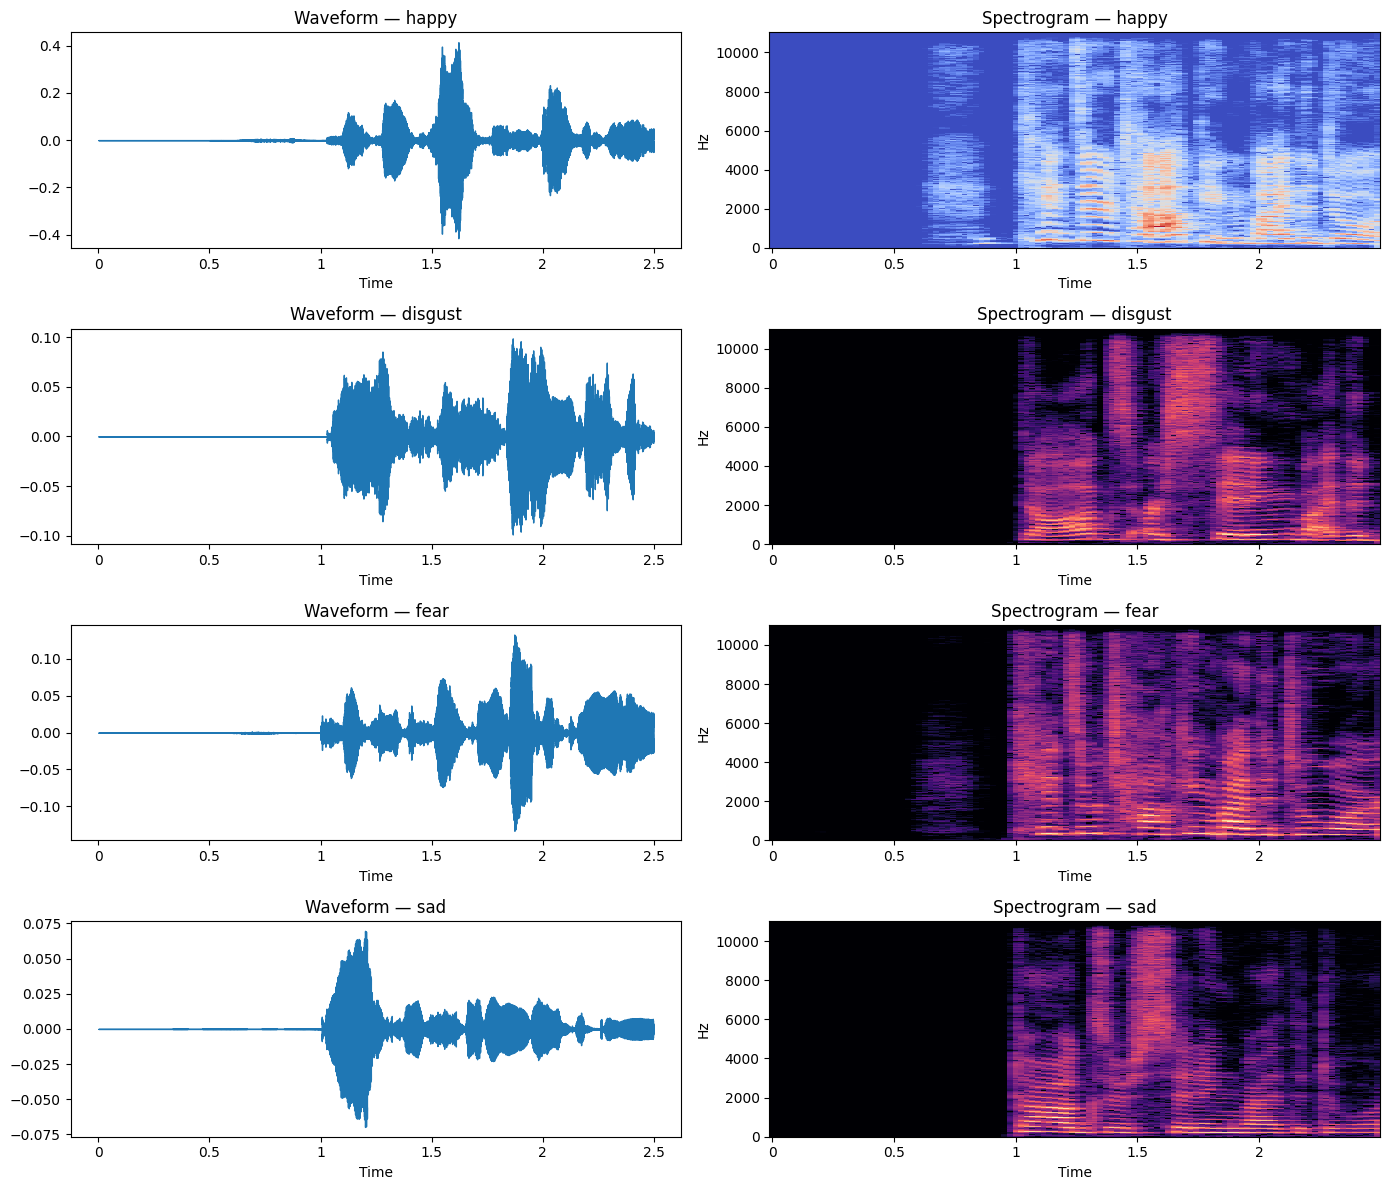

In [ ]:
# ── Visualise waveform & spectrogram for each emotion ────────
sample_emotions = data_path['Emotion'].unique()[:4]
fig, axes = plt.subplots(len(sample_emotions), 2, figsize=(14, 3*len(sample_emotions)))

for i, em in enumerate(sample_emotions):
    sample_path = data_path[data_path['Emotion']==em]['Path'].values[0]
    data_audio, sr = librosa.load(sample_path, duration=2.5)

    # Waveform
    librosa.display.waveshow(data_audio, sr=sr, ax=axes[i][0])
    axes[i][0].set_title(f'Waveform — {em}')

    # Spectrogram
    X = librosa.stft(data_audio)
    Xdb = librosa.amplitude_to_db(np.abs(X))
    librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz', ax=axes[i][1])
    axes[i][1].set_title(f'Spectrogram — {em}')

plt.tight_layout(); plt.show()

In [ ]:
# ── Extract features (cached) ────────────────────────────────
if os.path.exists('/content/ser_features.csv'):
    Features = pd.read_csv('/content/ser_features.csv')
    print("✅ Loaded cached features:", Features.shape)
else:
    print(f"Extracting features from {len(data_path)} files (with 4x augmentation)...")
    X_all, Y_all = [], []
    for i, (path, emotion) in enumerate(zip(data_path.Path, data_path.Emotion)):
        try:
            for feat in get_features(path):
                X_all.append(feat)
                Y_all.append(emotion)
        except Exception:
            pass
        if (i+1) % 100 == 0:
            print(f"  {i+1}/{len(data_path)} done...")

    Features = pd.DataFrame(X_all)
    Features['label'] = Y_all
    Features.to_csv('/content/ser_features.csv', index=False)
    print("✅ Done! Features shape:", Features.shape)

Extracting features from 1440 files (with 4x augmentation)...
  100/1440 done...
  200/1440 done...
  300/1440 done...
  400/1440 done...
  500/1440 done...
  600/1440 done...
  700/1440 done...
  800/1440 done...
  900/1440 done...
  1000/1440 done...
  1100/1440 done...
  1200/1440 done...
  1300/1440 done...
  1400/1440 done...
✅ Done! Features shape: (5760, 163)


In [ ]:
# ── Prepare training data ────────────────────────────────────
X = Features.iloc[:, :-1].values
Y = Features['label'].values

encoder_ser = OneHotEncoder(sparse_output=False)
Y_enc = encoder_ser.fit_transform(Y.reshape(-1,1))

x_train, x_test, y_train, y_test = train_test_split(
    X, Y_enc, test_size=0.2, random_state=42, shuffle=True)

scaler_ser = StandardScaler()
x_train = scaler_ser.fit_transform(x_train)
x_test  = scaler_ser.transform(x_test)
x_train = np.expand_dims(x_train, axis=2)
x_test  = np.expand_dims(x_test,  axis=2)

print(f"Train: {x_train.shape} | Test: {x_test.shape} | Classes: {y_train.shape[1]}")

Train: (4608, 162, 1) | Test: (1152, 162, 1) | Classes: 8


In [ ]:
# ── Build Conv1D model ───────────────────────────────────────
n_classes_ser = y_train.shape[1]

ser_model = Sequential([
    Conv1D(256, 5, padding='same', activation='relu', input_shape=(x_train.shape[1], 1)),
    BatchNormalization(), MaxPooling1D(pool_size=5, strides=2, padding='same'),

    Conv1D(128, 5, padding='same', activation='relu'),
    BatchNormalization(), MaxPooling1D(pool_size=5, strides=2, padding='same'),

    Conv1D(64, 5, padding='same', activation='relu'),
    BatchNormalization(), MaxPooling1D(pool_size=5, strides=2, padding='same'),
    Dropout(0.3),

    Flatten(),
    Dense(128, activation='relu'), Dropout(0.3),
    Dense(64,  activation='relu'), Dropout(0.2),
    Dense(n_classes_ser, activation='softmax')
])
ser_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
ser_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 162, 256)       │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 162, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 81, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 81, 128)        │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 81, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 41, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 41, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 41, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 21, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 21, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1344)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       172,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 389,256 (1.48 MB)

 Trainable params: 388,360 (1.48 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.2146 - loss: 2.2466

72/72 ━━━━━━━━━━━━━━━━━━━━ 25s 293ms/step - accuracy: 0.2389 - loss: 2.0607 - val_accuracy: 0.2465 - val_loss: 1.9639 - learning_rate: 0.0010
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 301ms/step - accuracy: 0.2878 - loss: 1.8525 - val_accuracy: 0.1484 - val_loss: 2.0929 - learning_rate: 0.0010
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 291ms/step - accuracy: 0.3190 - loss: 1.7646 - val_accuracy: 0.1649 - val_loss: 2.0080 - learning_rate: 0.0010
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.3311 - loss: 1.6884
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0004000000189989805.
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 293ms/step - accuracy: 0.3427 - loss: 1.7011 - val_accuracy: 0.1675 - val_loss: 2.0824 - learning_rate: 0.0010
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 306ms/step - accuracy: 0.3854 - loss: 1.6034 - val_accuracy: 0.1823 - val_loss: 2.0418 - learning_rate: 4.0000e-04
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.4027 - loss: 1.5535

72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 290ms/step - accuracy: 0.3989 - loss: 1.5654 - val_accuracy: 0.2040 - val_loss: 1.8854 - learning_rate: 4.0000e-04
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 23s 316ms/step - accuracy: 0.4121 - loss: 1.5454 - val_accuracy: 0.2031 - val_loss: 1.9607 - learning_rate: 4.0000e-04
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.4344 - loss: 1.4861

72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 298ms/step - accuracy: 0.4371 - loss: 1.4907 - val_accuracy: 0.4323 - val_loss: 1.5221 - learning_rate: 4.0000e-04
Epoch 9/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.4421 - loss: 1.4545

72/72 ━━━━━━━━━━━━━━━━━━━━ 22s 298ms/step - accuracy: 0.4403 - loss: 1.4603 - val_accuracy: 0.4227 - val_loss: 1.4926 - learning_rate: 4.0000e-04
Epoch 10/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.4694 - loss: 1.4198

...

72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 293ms/step - accuracy: 0.8086 - loss: 0.5303 - val_accuracy: 0.7413 - val_loss: 0.7405 - learning_rate: 1.6000e-04
Epoch 38/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 280ms/step - accuracy: 0.8190 - loss: 0.5053 - val_accuracy: 0.7309 - val_loss: 0.8171 - learning_rate: 1.6000e-04
Epoch 39/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.8418 - loss: 0.4534

72/72 ━━━━━━━━━━━━━━━━━━━━ 19s 259ms/step - accuracy: 0.8318 - loss: 0.4617 - val_accuracy: 0.7517 - val_loss: 0.7191 - learning_rate: 1.6000e-04
Epoch 40/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 19s 269ms/step - accuracy: 0.8405 - loss: 0.4361 - val_accuracy: 0.7396 - val_loss: 0.7973 - learning_rate: 1.6000e-04
Epoch 41/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 264ms/step - accuracy: 0.8416 - loss: 0.4313 - val_accuracy: 0.7613 - val_loss: 0.7408 - learning_rate: 1.6000e-04
Epoch 42/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.8543 - loss: 0.4057
Epoch 42: ReduceLROnPlateau reducing learning rate to 6.40000042039901e-05.
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 287ms/step - accuracy: 0.8416 - loss: 0.4328 - val_accuracy: 0.6658 - val_loss: 1.1669 - learning_rate: 1.6000e-04
Epoch 43/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.8642 - loss: 0.3879

72/72 ━━━━━━━━━━━━━━━━━━━━ 19s 267ms/step - accuracy: 0.8650 - loss: 0.3839 - val_accuracy: 0.7760 - val_loss: 0.6937 - learning_rate: 6.4000e-05
Epoch 44/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.8771 - loss: 0.3513

72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 285ms/step - accuracy: 0.8685 - loss: 0.3665 - val_accuracy: 0.7986 - val_loss: 0.6417 - learning_rate: 6.4000e-05
Epoch 45/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 19s 267ms/step - accuracy: 0.8798 - loss: 0.3425 - val_accuracy: 0.7899 - val_loss: 0.6512 - learning_rate: 6.4000e-05
Epoch 46/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 286ms/step - accuracy: 0.8819 - loss: 0.3364 - val_accuracy: 0.7977 - val_loss: 0.6420 - learning_rate: 6.4000e-05
Epoch 47/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.8787 - loss: 0.3514

72/72 ━━━━━━━━━━━━━━━━━━━━ 19s 259ms/step - accuracy: 0.8800 - loss: 0.3435 - val_accuracy: 0.8038 - val_loss: 0.6169 - learning_rate: 6.4000e-05
Epoch 48/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 275ms/step - accuracy: 0.8843 - loss: 0.3338 - val_accuracy: 0.7882 - val_loss: 0.6846 - learning_rate: 6.4000e-05
Epoch 49/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 266ms/step - accuracy: 0.8893 - loss: 0.3034 - val_accuracy: 0.7804 - val_loss: 0.6842 - learning_rate: 6.4000e-05
Epoch 50/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.8831 - loss: 0.3187
Epoch 50: ReduceLROnPlateau reducing learning rate to 2.560000284574926e-05.
72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 276ms/step - accuracy: 0.8863 - loss: 0.3140 - val_accuracy: 0.8003 - val_loss: 0.6447 - learning_rate: 6.4000e-05
Restoring model weights from the end of the best epoch: 47.


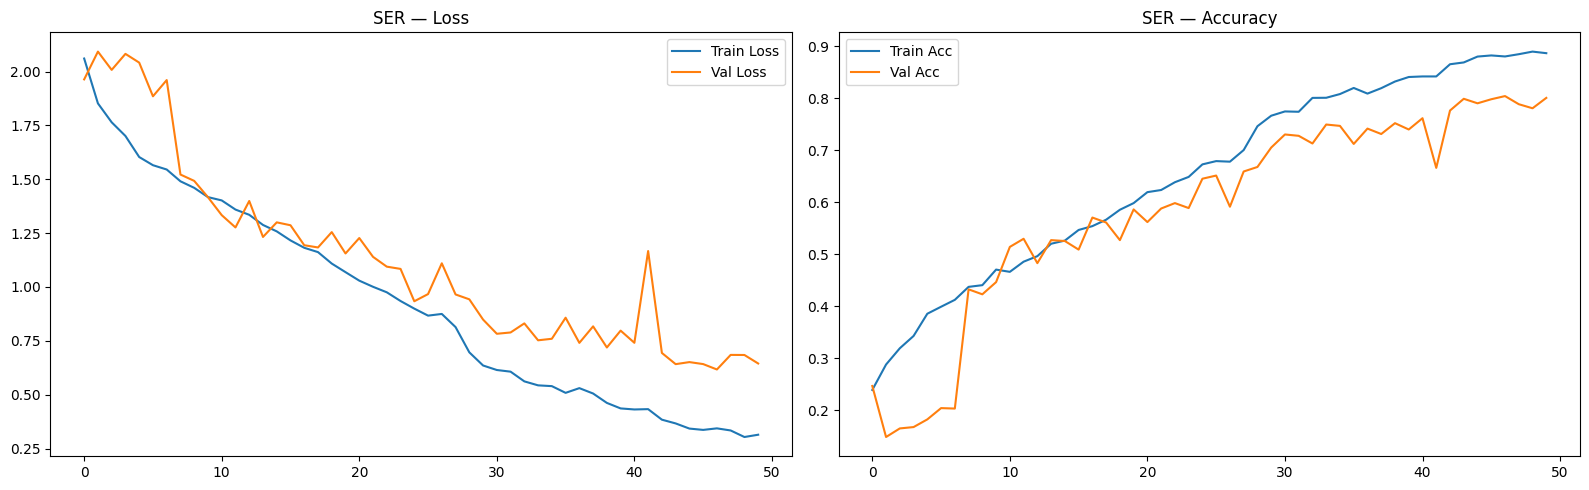


✅ SER Test Accuracy: 80.38%


In [ ]:
# ── Train ────────────────────────────────────────────────────
callbacks_ser = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=3, min_lr=1e-7, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint('/content/ser_model_best.h5', save_best_only=True, verbose=0)
]

history_ser = ser_model.fit(
    x_train, y_train, batch_size=64, epochs=50,
    validation_data=(x_test, y_test), callbacks=callbacks_ser
)

# ── Plot results ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(history_ser.history['loss'],     label='Train Loss')
axes[0].plot(history_ser.history['val_loss'], label='Val Loss')
axes[0].set_title('SER — Loss'); axes[0].legend()
axes[1].plot(history_ser.history['accuracy'],     label='Train Acc')
axes[1].plot(history_ser.history['val_accuracy'], label='Val Acc')
axes[1].set_title('SER — Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

test_loss, test_acc = ser_model.evaluate(x_test, y_test, verbose=0)
print(f"\n✅ SER Test Accuracy: {test_acc*100:.2f}%")

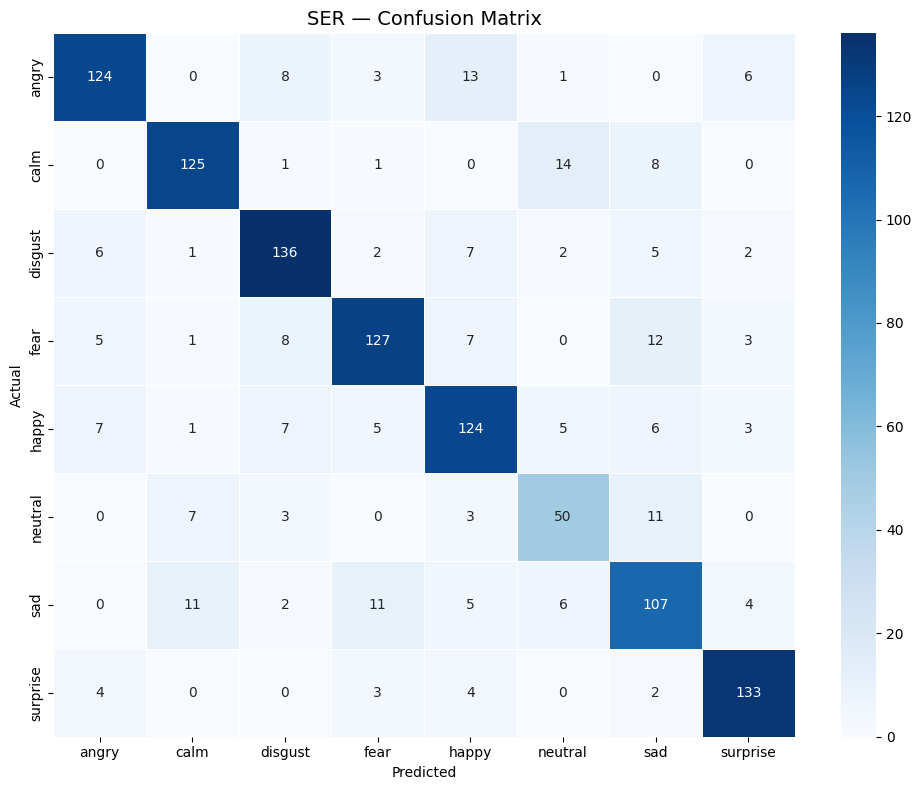

              precision    recall  f1-score   support

       angry       0.85      0.80      0.82       155
        calm       0.86      0.84      0.85       149
     disgust       0.82      0.84      0.83       161
        fear       0.84      0.78      0.81       163
       happy       0.76      0.78      0.77       158
     neutral       0.64      0.68      0.66        74
         sad       0.71      0.73      0.72       146
    surprise       0.88      0.91      0.90       146

    accuracy                           0.80      1152
   macro avg       0.79      0.80      0.79      1152
weighted avg       0.81      0.80      0.80      1152



In [ ]:
# ── Confusion Matrix ─────────────────────────────────────────
pred_test   = ser_model.predict(x_test, verbose=0)
y_pred_ser  = encoder_ser.inverse_transform(pred_test).flatten()
y_true_ser  = encoder_ser.inverse_transform(y_test).flatten()

cm = confusion_matrix(y_true_ser, y_pred_ser)
labels = encoder_ser.categories_[0]
plt.figure(figsize=(10, 8))
sns.heatmap(pd.DataFrame(cm, index=labels, columns=labels),
            annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title('SER — Confusion Matrix', fontsize=14)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

print(classification_report(y_true_ser, y_pred_ser))

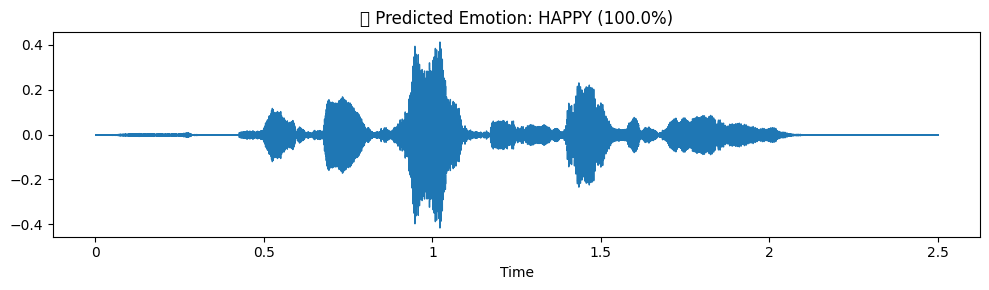


🎤 Speech Emotion: HAPPY | Confidence: 100.0%


'happy'

In [ ]:
# ── Predict from any audio file ─────────────────────────────
def predict_speech_emotion(audio_path):
    data, sr = librosa.load(audio_path, duration=2.5, offset=0.6)
    feat = extract_features(data, sr).reshape(1, -1)
    feat = scaler_ser.transform(feat)
    feat = np.expand_dims(feat, axis=2)
    pred = ser_model.predict(feat, verbose=0)
    label = encoder_ser.inverse_transform(pred)[0][0]
    conf  = np.max(pred) * 100

    plt.figure(figsize=(10, 3))
    librosa.display.waveshow(data, sr=sr)
    plt.title(f"🎤 Predicted Emotion: {label.upper()} ({conf:.1f}%)")
    plt.tight_layout(); plt.show()

    print(f"\n🎤 Speech Emotion: {label.upper()} | Confidence: {conf:.1f}%")
    return label

# ── Test on a sample from the dataset ───────────────────────
sample_wav = data_path['Path'].iloc[0]
predict_speech_emotion(sample_wav)

In [ ]:
# ── Load Twitter Emotion dataset from HuggingFace ────────────
from datasets import load_dataset

print("⬇️  Loading Twitter Emotion dataset from HuggingFace Hub...")
emotion_dataset = load_dataset("dair-ai/emotion", trust_remote_code=True)

TWITTER_LABELS = emotion_dataset['train'].features['label'].names
print(f"✅ Dataset loaded! Labels: {TWITTER_LABELS}")
print(f"Train: {len(emotion_dataset['train'])} | Val: {len(emotion_dataset['validation'])} | Test: {len(emotion_dataset['test'])}")

# Preview
df_twitter = pd.DataFrame(emotion_dataset['train'])
df_twitter['emotion'] = df_twitter['label'].map(dict(enumerate(TWITTER_LABELS)))
df_twitter.head(8)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'dair-ai/emotion' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'dair-ai/emotion' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


⬇️  Loading Twitter Emotion dataset from HuggingFace Hub...


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:01<?, ? examples/s]

✅ Dataset loaded! Labels: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Train: 16000 | Val: 2000 | Test: 2000


,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger
5,ive been feeling a little burdened lately wasn...,0,sadness
6,ive been taking or milligrams or times recomme...,5,surprise
7,i feel as confused about life as a teenager or...,4,fear


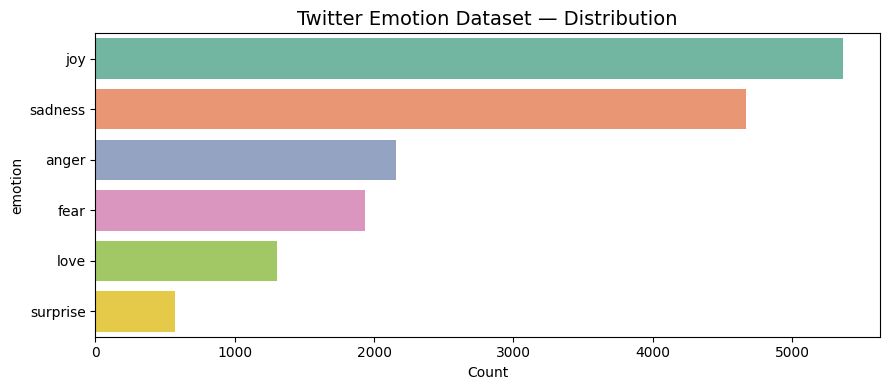

In [ ]:
# ── Visualise label distribution ─────────────────────────────
plt.figure(figsize=(9, 4))
vc = df_twitter['emotion'].value_counts()
sns.barplot(x=vc.values, y=vc.index, palette='Set2')
plt.title('Twitter Emotion Dataset — Distribution', fontsize=14)
plt.xlabel('Count'); plt.tight_layout(); plt.show()

In [ ]:
# ── Full preprocessing pipeline from reference notebooks ─────
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()                                    # 1. Lowercase
    text = re.sub(r'<.*?>', '', text)                           # 2. Remove HTML
    text = re.sub(r'https?://\S+|www\.\S+', '', text)       # 3. Remove URLs
    text = text.translate(str.maketrans('', '', string.punctuation))  # 4. Remove punctuation
    text = re.sub(r'\d+', '', text)                            # 5. Remove numbers
    text = re.sub(r'\s+', ' ', text).strip()                  # 6. Normalise whitespace
    tokens = word_tokenize(text)                                 # 7. Tokenise
    tokens = [lemmatizer.lemmatize(t) for t in tokens          # 8. Lemmatise + remove stopwords
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

# Apply to dataset
df_twitter['cleaned'] = df_twitter['text'].apply(clean_text)
print("=== Preprocessing Demo (first 3 rows) ===")
for _, row in df_twitter.head(3).iterrows():
    print(f"Original : {row['text']}")
    print(f"Cleaned  : {row['cleaned']}")
    print(f"Emotion  : {row['emotion']}\n")


=== Preprocessing Demo (first 3 rows) ===
Original : i didnt feel humiliated
Cleaned  : didnt feel humiliated
Emotion  : sadness

Original : i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Cleaned  : feeling hopeless damned hopeful around someone care awake
Emotion  : sadness

Original : im grabbing a minute to post i feel greedy wrong
Cleaned  : grabbing minute post feel greedy wrong
Emotion  : anger



In [ ]:
vader_analyzer = SentimentIntensityAnalyzer()

def full_text_analysis(text):
    """VADER + TextBlob combined analysis."""
    cleaned  = clean_text(text)
    # VADER
    scores   = vader_analyzer.polarity_scores(cleaned)
    compound = scores['compound']
    if compound >= 0.05:   vader_sentiment = 'Positive 😊'
    elif compound <= -0.05: vader_sentiment = 'Negative 😠'
    else:                  vader_sentiment = 'Neutral 😐'

    # TextBlob
    blob = TextBlob(cleaned)
    tb_polarity = blob.sentiment.polarity
    if tb_polarity > 0.1:   tb_sentiment = 'Positive 😊'
    elif tb_polarity < -0.1: tb_sentiment = 'Negative 😔'
    else:                   tb_sentiment = 'Neutral 😐'

    # Keyword-based emotion
    kw_map = {
        'joy':      ['happy','joy','love','great','wonderful','excited','glad'],
        'anger':    ['angry','furious','hate','rage','mad','annoyed','terrible'],
        'sadness':  ['sad','cry','unhappy','depressed','miss','lonely','grief'],
        'fear':     ['fear','scared','afraid','terror','anxious','worry'],
        'surprise': ['surprised','shocked','wow','unbelievable','amazed'],
        'love':     ['love','adore','cherish','affection','caring','devoted']
    }
    kw_tokens = set(cleaned.split())
    kw_scores = {e: len(kw_tokens & set(ws)) for e, ws in kw_map.items()}
    kw_emotion = max(kw_scores, key=kw_scores.get) if max(kw_scores.values()) > 0 else 'neutral'

    return {
        'text': text, 'cleaned': cleaned,
        'vader_sentiment': vader_sentiment, 'vader_compound': round(compound, 4),
        'tb_sentiment': tb_sentiment, 'tb_polarity': round(tb_polarity, 4),
        'tb_subjectivity': round(blob.sentiment.subjectivity, 4),
        'keyword_emotion': kw_emotion
    }

# ── Test on Twitter dataset samples ──────────────────────────
print("=== Sentiment Analysis on Twitter Emotion Dataset ===\n")
for _, row in df_twitter.sample(5, random_state=42).iterrows():
    r = full_text_analysis(row['text'])
    print(f"Text          : {r['text'][:70]}")
    print(f"True Emotion  : {row['emotion'].upper()}")
    print(f"VADER         : {r['vader_sentiment']} (compound={r['vader_compound']})")
    print(f"TextBlob      : {r['tb_sentiment']} (pol={r['tb_polarity']})")
    print(f"Keyword Emotion: {r['keyword_emotion'].upper()}\n")

=== Sentiment Analysis on Twitter Emotion Dataset ===

Text          : ive made it through a week i just feel beaten down
True Emotion  : SADNESS
VADER         : Negative 😠 (compound=-0.4215)
TextBlob      : Neutral 😐 (pol=0.0)
Keyword Emotion: NEUTRAL

Text          : i feel this strategy is worthwhile
True Emotion  : JOY
VADER         : Positive 😊 (compound=0.34)
TextBlob      : Positive 😊 (pol=0.5)
Keyword Emotion: NEUTRAL

Text          : i feel so worthless and weak what does he have to say that s what i wa
True Emotion  : SADNESS
VADER         : Negative 😠 (compound=-0.6705)
TextBlob      : Negative 😔 (pol=-0.5875)
Keyword Emotion: NEUTRAL

Text          : i feel clever nov
True Emotion  : JOY
VADER         : Positive 😊 (compound=0.4588)
TextBlob      : Positive 😊 (pol=0.1667)
Keyword Emotion: NEUTRAL

Text          : im moved in ive been feeling kind of gloomy
True Emotion  : SADNESS
VADER         : Positive 😊 (compound=0.5106)
TextBlob      : Positive 😊 (pol=0.6)
Keyword Emotio

In [ ]:
from transformers import pipeline as hf_pipeline

print("⬇️  Loading emotion transformer (distilroberta, ~130MB, first run only)...")
emotion_pipe = hf_pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None, device=-1   # set device=0 to use GPU
)
print("✅ Transformer model loaded!")

⬇️  Loading emotion transformer (distilroberta, ~130MB, first run only)...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

✅ Transformer model loaded!


=== Transformer Predictions on Twitter Dataset ===

Text: i feel increasingly energetic and comfortable inside and out
True: JOY


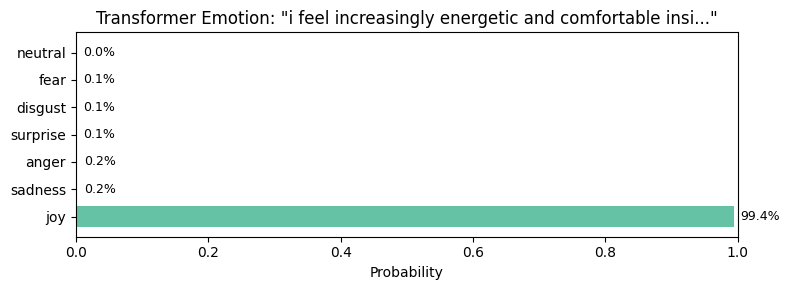

🏆 Top emotion: JOY (99.4%)

Text: i drove to class i was feeling a little apprehensive but still no sweat
True: FEAR


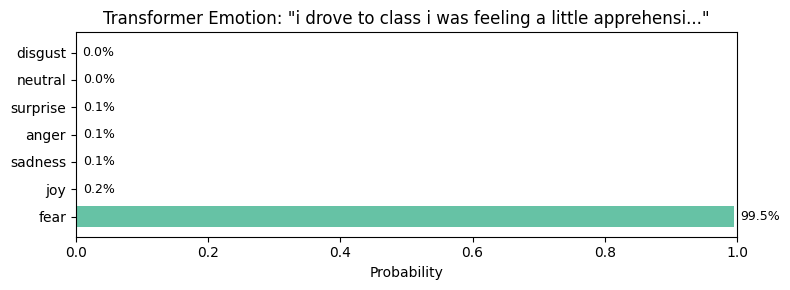

🏆 Top emotion: FEAR (99.5%)

Text: im putting my books in a stack and wondering when ill stop feeling so sad about 
True: SADNESS


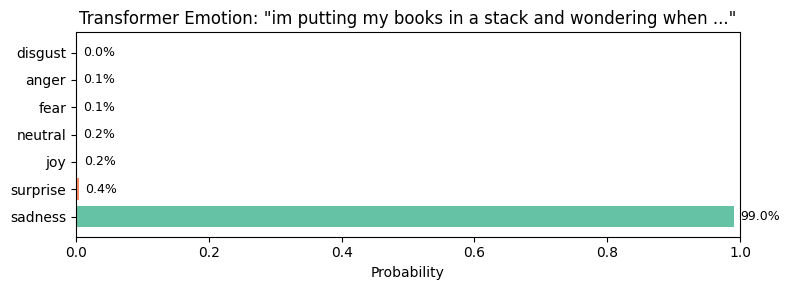

🏆 Top emotion: SADNESS (99.0%)

Text: i feel pressured helpless because i dont have control over this
True: FEAR


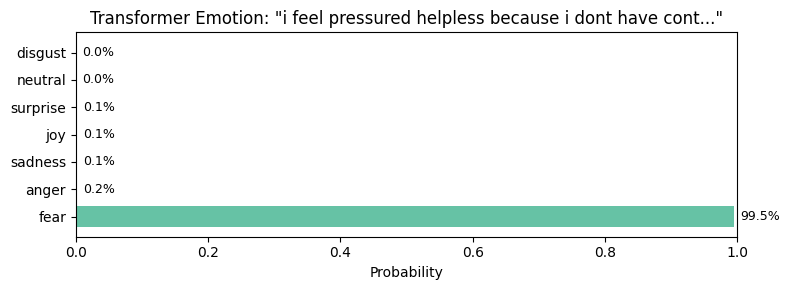

🏆 Top emotion: FEAR (99.5%)



In [ ]:
def predict_emotion_transformer(text, show_bar=True):
    """Predict emotion probabilities using DistilRoBERTa."""
    results = sorted(emotion_pipe(text[:512])[0], key=lambda x: x['score'], reverse=True)
    top = results[0]

    if show_bar:
        labels = [r['label'] for r in results]
        scores = [r['score'] for r in results]
        colors = plt.cm.Set2(np.linspace(0, 1, len(labels)))
        plt.figure(figsize=(8, 3))
        bars = plt.barh(labels, scores, color=colors)
        plt.xlim(0, 1); plt.xlabel('Probability')
        plt.title(f'Transformer Emotion: "{text[:50]}..."')
        for bar, sc in zip(bars, scores):
            plt.text(sc + 0.01, bar.get_y() + bar.get_height()/2,
                     f'{sc*100:.1f}%', va='center', fontsize=9)
        plt.tight_layout(); plt.show()

    print(f"🏆 Top emotion: {top['label'].upper()} ({top['score']*100:.1f}%)")
    return top['label'], top['score']

# ── Test on Twitter samples ───────────────────────────────────
print("=== Transformer Predictions on Twitter Dataset ===\n")
for _, row in df_twitter.sample(4, random_state=7).iterrows():
    print(f"Text: {row['text'][:80]}")
    print(f"True: {row['emotion'].upper()}")
    predict_emotion_transformer(row['text'])
    print()

Running batch analysis on 500 test samples...


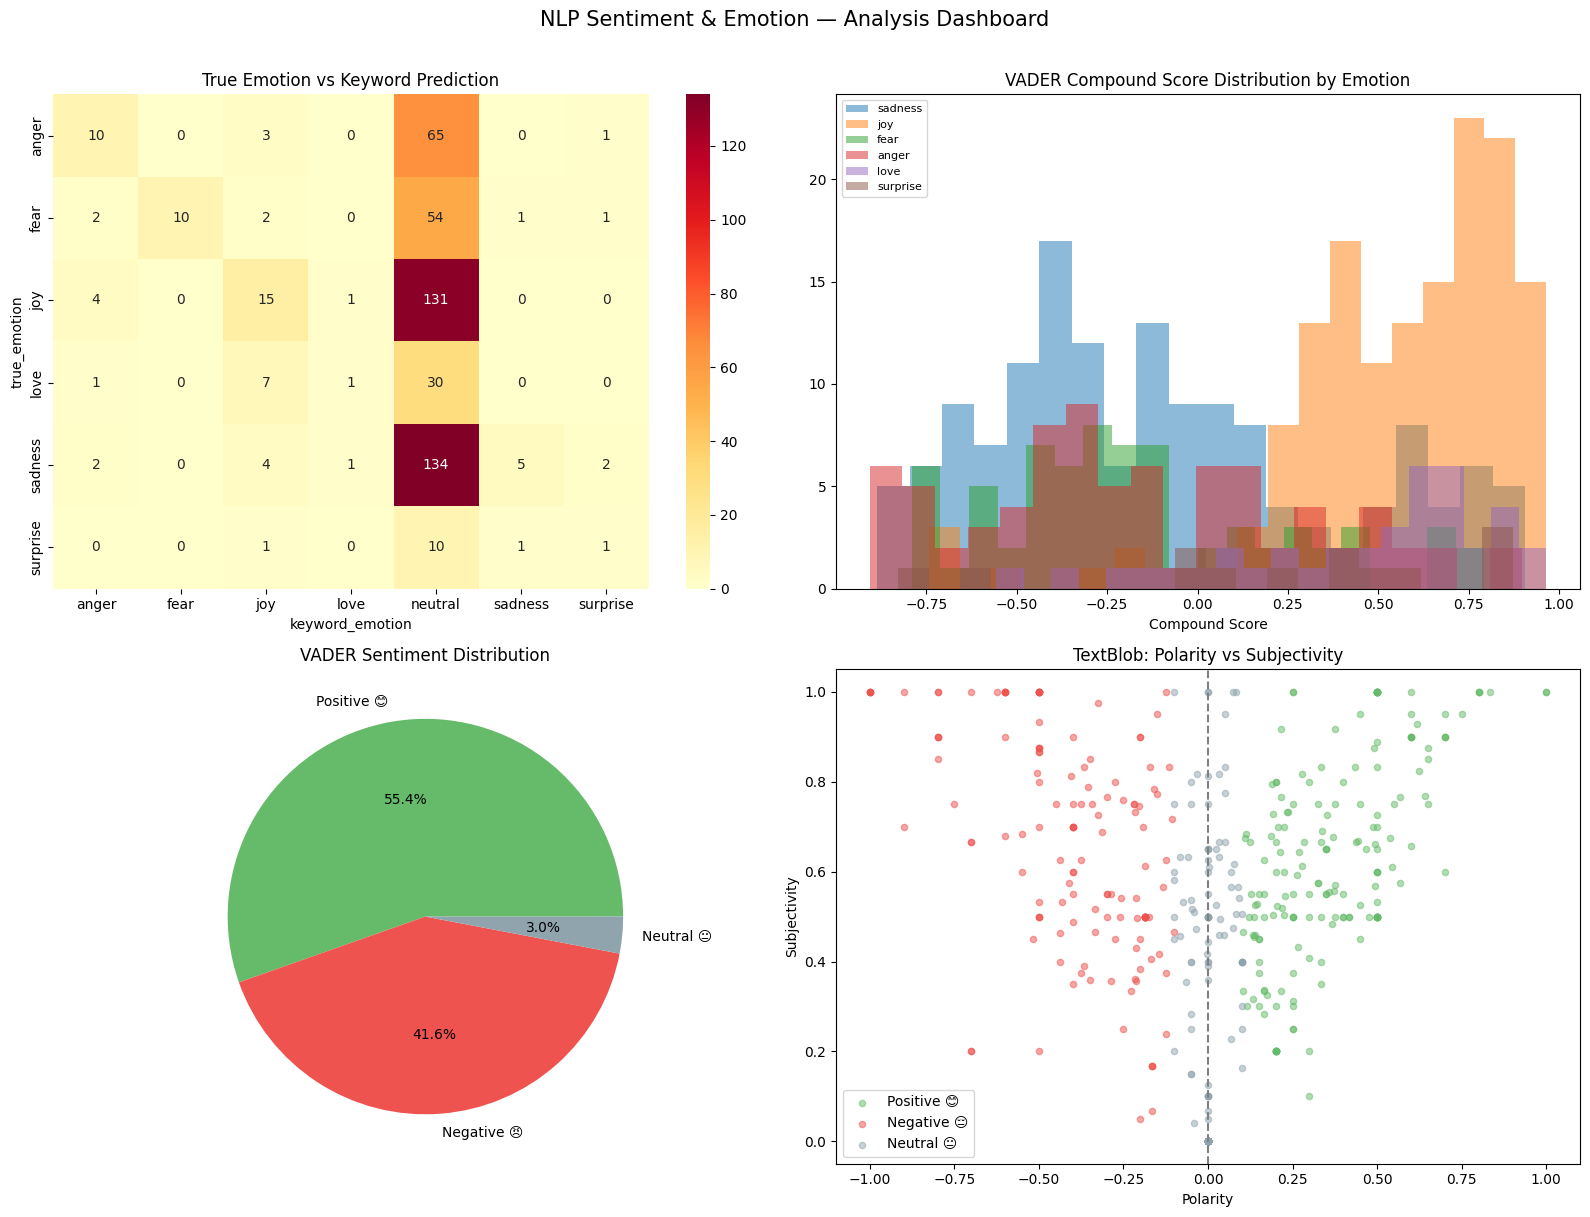

✅ Batch analysis complete on 500 samples.


In [ ]:
# ── Run full VADER analysis on test set ──────────────────────
print("Running batch analysis on 500 test samples...")
df_test = pd.DataFrame(emotion_dataset['test']).head(500)
df_test['emotion_name'] = df_test['label'].map(dict(enumerate(TWITTER_LABELS)))

results_list = [full_text_analysis(t) for t in df_test['text']]
df_results = pd.DataFrame(results_list)
df_results['true_emotion'] = df_test['emotion_name'].values

# ── Dashboard ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. True vs Keyword emotion heatmap
ct = pd.crosstab(df_results['true_emotion'], df_results['keyword_emotion'])
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0][0])
axes[0][0].set_title('True Emotion vs Keyword Prediction', fontsize=12)

# 2. VADER compound distribution per emotion
for em in df_results['true_emotion'].unique():
    subset = df_results[df_results['true_emotion']==em]['vader_compound']
    axes[0][1].hist(subset, alpha=0.5, label=em, bins=20)
axes[0][1].set_title('VADER Compound Score Distribution by Emotion')
axes[0][1].legend(fontsize=8); axes[0][1].set_xlabel('Compound Score')

# 3. Sentiment distribution pie
vc_sent = df_results['vader_sentiment'].value_counts()
axes[1][0].pie(vc_sent, labels=vc_sent.index, autopct='%1.1f%%',
               colors=['#66bb6a','#ef5350','#90a4ae'])
axes[1][0].set_title('VADER Sentiment Distribution')

# 4. TextBlob polarity vs subjectivity
colors_map = {'Positive 😊':'#66bb6a','Negative 😔':'#ef5350','Neutral 😐':'#90a4ae'}
for sent, col in colors_map.items():
    mask = df_results['tb_sentiment'] == sent
    axes[1][1].scatter(df_results[mask]['tb_polarity'],
                       df_results[mask]['tb_subjectivity'],
                       c=col, alpha=0.5, label=sent, s=20)
axes[1][1].set_xlabel('Polarity'); axes[1][1].set_ylabel('Subjectivity')
axes[1][1].set_title('TextBlob: Polarity vs Subjectivity')
axes[1][1].axvline(0, color='gray', ls='--'); axes[1][1].legend()

plt.suptitle('NLP Sentiment & Emotion — Analysis Dashboard', fontsize=15, y=1.01)
plt.tight_layout(); plt.show()
print(f"✅ Batch analysis complete on {len(df_results)} samples.")

🧠  MULTIMODAL EMOTION DETECTION — UNIFIED REPORT

📝 TEXT ANALYSIS
────────────────────────────────────────
  Input     : I am so happy and excited about this amazing project! It turned out wo
  Cleaned   : happy excited amazing project turned wonderful
  VADER     : Positive 😊  (compound=0.9274)
  TextBlob  : Positive 😊  (pol=0.6938, subj=0.9125)


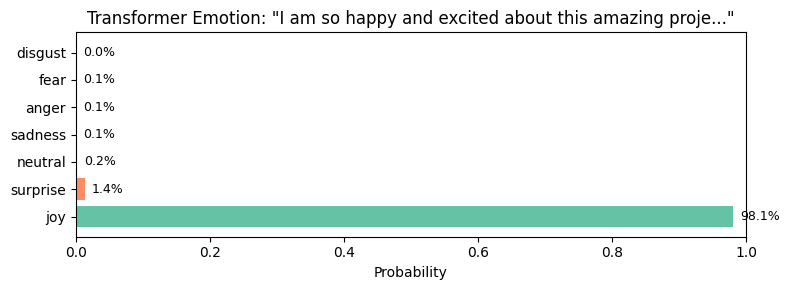

🏆 Top emotion: JOY (98.1%)
  Transformer: JOY (98.1%)

🎤 SPEECH ANALYSIS
────────────────────────────────────────


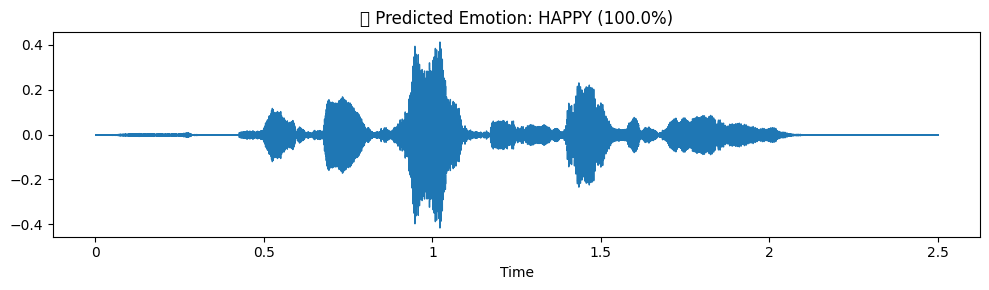


🎤 Speech Emotion: HAPPY | Confidence: 100.0%

😊 FACIAL: Call webcam_emotion_predict() for live detection.

📊  FINAL SUMMARY
  text_emotion        : JOY
  text_sentiment      : POSITIVE 😊
  speech_emotion      : HAPPY


In [ ]:
def multimodal_emotion_report(text_input=None, audio_path=None, image_path=None):
    """
    Unified emotion detection across all three modalities.
    Pass any combination of text, audio path, or image path.
    """
    print("=" * 65)
    print("🧠  MULTIMODAL EMOTION DETECTION — UNIFIED REPORT")
    print("=" * 65)
    results = {}

    # ── 📝 TEXT ───────────────────────────────────────────────
    if text_input:
        print("\n📝 TEXT ANALYSIS")
        print("─" * 40)
        r = full_text_analysis(text_input)
        print(f"  Input     : {text_input[:70]}")
        print(f"  Cleaned   : {r['cleaned'][:70]}")
        print(f"  VADER     : {r['vader_sentiment']}  (compound={r['vader_compound']})")
        print(f"  TextBlob  : {r['tb_sentiment']}  (pol={r['tb_polarity']}, subj={r['tb_subjectivity']})")
        try:
            em, sc = predict_emotion_transformer(text_input, show_bar=True)
            print(f"  Transformer: {em.upper()} ({sc*100:.1f}%)")
            results['text_emotion'] = em
        except:
            results['text_emotion'] = r['keyword_emotion']
        results['text_sentiment'] = r['vader_sentiment']

    # ── 🎤 SPEECH ─────────────────────────────────────────────
    if audio_path and os.path.exists(audio_path):
        print("\n🎤 SPEECH ANALYSIS")
        print("─" * 40)
        label = predict_speech_emotion(audio_path)
        results['speech_emotion'] = label
    elif audio_path:
        print(f"\n🎤 Audio not found: {audio_path}")

    # ── 😊 FACE ───────────────────────────────────────────────
    if image_path and os.path.exists(image_path):
        print("\n😊 FACIAL ANALYSIS")
        print("─" * 40)
        predict_face_emotion(image_path)
    else:
        print("\n😊 FACIAL: Call webcam_emotion_predict() for live detection.")

    # ── Summary ───────────────────────────────────────────────
    print("\n" + "=" * 65)
    print("📊  FINAL SUMMARY")
    for k, v in results.items():
        print(f"  {k:20s}: {str(v).upper()}")
    print("=" * 65)
    return results

# ── DEMO RUN ──────────────────────────────────────────────────
demo = multimodal_emotion_report(
    text_input="I am so happy and excited about this amazing project! It turned out wonderful.",
    audio_path=data_path['Path'].iloc[0] if len(data_path) > 0 else None,
    image_path=None
)